In [2]:
import requests

In [4]:
pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Note: you may need to restart the kernel to use updated packages.


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import requests

In [10]:
from pathlib import Path

PROJECT_ROOT = Path.cwd()

print(list((PROJECT_ROOT / "data" / "external").glob("*")))

[WindowsPath('C:/Users/PC/MI-Matcha-SystemsBio/data/external/SwissTargetPrediction.csv')]


In [12]:
import pandas as pd
from pathlib import Path

PROJECT_ROOT = Path.cwd()

targets = pd.read_csv(
    PROJECT_ROOT / "data" / "external" / "SwissTargetPrediction.csv"
)

gene_list = (
    targets["Common name"]
    .dropna()
    .unique()
    .tolist()
)

print(f"Number of genes: {len(gene_list)}")
print(gene_list[:10])

Number of genes: 96
['DYRK1A', 'KCNH2', 'BACE1', 'DYRK1B', 'ADAMTS5', 'DYRK4', 'CLK4', 'DYRK2', 'MAPKAPK5', 'MAPK14']


In [13]:
import requests
import pandas as pd
from io import StringIO

string_api_url = "https://string-db.org/api/tsv/network"

params = {
    "identifiers": "\r".join(gene_list),
    "species": 9606,
    "required_score": 400,
    "network_type": "functional",
    "caller_identity": "MI-Matcha-SystemsBio"
}

response = requests.post(
    string_api_url,
    data=params,
    timeout=60
)

print("Status code:", response.status_code)
print(response.text[:300])

Status code: 200
stringId_A	stringId_B	preferredName_A	preferredName_B	ncbiTaxonId	score	nscore	fscore	pscore	ascore	escore	dscore	tscore
9606.ENSP00000178638	9606.ENSP00000405330	CA12	ESR1	9606	0.403	0	0	0	0.067	0.041	0	0.387
9606.ENSP00000178638	9606.ENSP00000345659	CA12	CA7	9606	0.405	0	0	0.116	0	0	0	0.355
9606.E


In [14]:
if response.status_code != 200:
    raise RuntimeError(
        f"STRING request failed: {response.status_code}\n"
        f"{response.text[:500]}"
    )

string_network = pd.read_csv(
    StringIO(response.text),
    sep="\t"
)

print("Number of interactions:", len(string_network))
string_network.head()

Number of interactions: 512


,stringId_A,stringId_B,preferredName_A,preferredName_B,ncbiTaxonId,score,nscore,fscore,pscore,ascore,escore,dscore,tscore
0,9606.ENSP00000178638,9606.ENSP00000405330,CA12,ESR1,9606,0.403,0.0,0.0,0.000,0.067,0.041,0.0,0.387
1,9606.ENSP00000178638,9606.ENSP00000345659,CA12,CA7,9606,0.405,0.0,0.0,0.116,0.000,0.000,0.0,0.355
2,9606.ENSP00000178638,9606.ENSP00000223095,CA12,SERPINE1,9606,0.406,0.0,0.0,0.000,0.086,0.000,0.0,0.377
3,9606.ENSP00000178638,9606.ENSP00000437955,CA12,HIF1A,9606,0.487,0.0,0.0,0.000,0.062,0.000,0.0,0.476
4,9606.ENSP00000178638,9606.ENSP00000430656,CA12,CA1,9606,0.488,0.0,0.0,0.118,0.000,0.000,0.0,0.444


In [15]:
NETWORK_DIR = PROJECT_ROOT / "outputs" / "networks"
NETWORK_DIR.mkdir(parents=True, exist_ok=True)

string_network.to_csv(
    NETWORK_DIR / "EGCG_STRING_network.csv",
    index=False
)

print("STRING network saved.")

STRING network saved.


In [16]:
pip install networkx

Note: you may need to restart the kernel to use updated packages.


In [18]:
degree = dict(G.degree())

hub_genes = (
    pd.DataFrame({
        "Gene": degree.keys(),
        "Degree": degree.values()
    })
    .sort_values("Degree", ascending=False)
)

hub_genes.head(20)

,Gene,Degree
27,BCL2,42
28,MMP9,40
4,HIF1A,40
1,ESR1,39
31,SRC,36
21,GSK3B,32
17,MTOR,29
24,KDR,28
8,MMP2,27
44,PIK3CA,23


In [19]:
print("Number of nodes:", G.number_of_nodes())
print("Number of edges:", G.number_of_edges())

Number of nodes: 93
Number of edges: 512


In [20]:
degree = dict(G.degree())

hub_genes = (
    pd.DataFrame({
        "Gene": degree.keys(),
        "Degree": degree.values()
    })
    .sort_values("Degree", ascending=False)
)

hub_genes.head(20)

,Gene,Degree
27,BCL2,42
28,MMP9,40
4,HIF1A,40
1,ESR1,39
31,SRC,36
21,GSK3B,32
17,MTOR,29
24,KDR,28
8,MMP2,27
44,PIK3CA,23


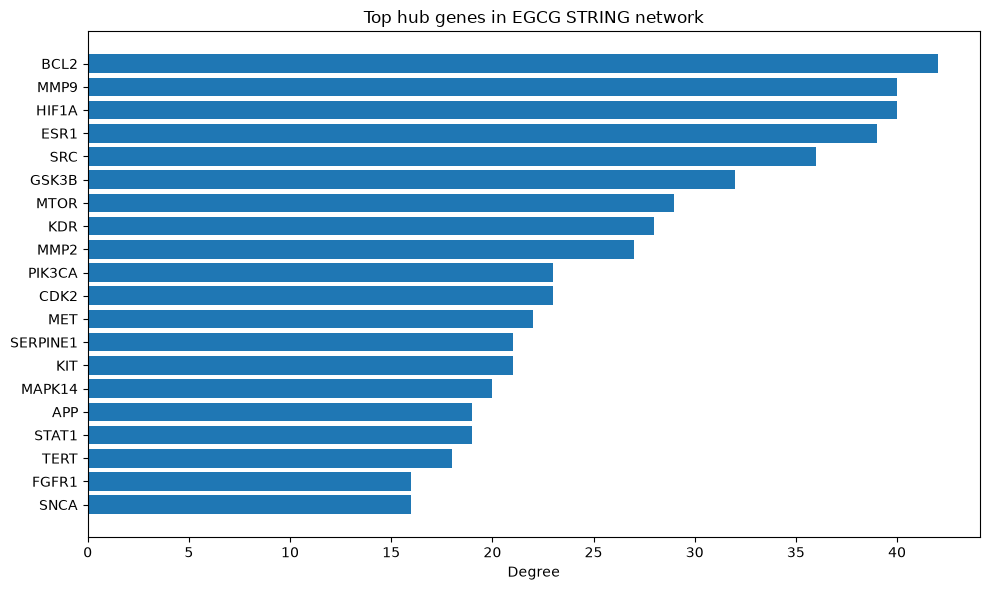

In [21]:
import matplotlib.pyplot as plt

top20 = hub_genes.head(20)

plt.figure(figsize=(10,6))

plt.barh(
    top20["Gene"],
    top20["Degree"]
)

plt.gca().invert_yaxis()

plt.title("Top hub genes in EGCG STRING network")
plt.xlabel("Degree")
plt.tight_layout()

plt.show()

In [22]:
hub_genes.to_csv(
    NETWORK_DIR / "EGCG_hub_genes.csv",
    index=False
)

print("Hub genes saved.")

Hub genes saved.


<Figure size 1000x600 with 0 Axes>

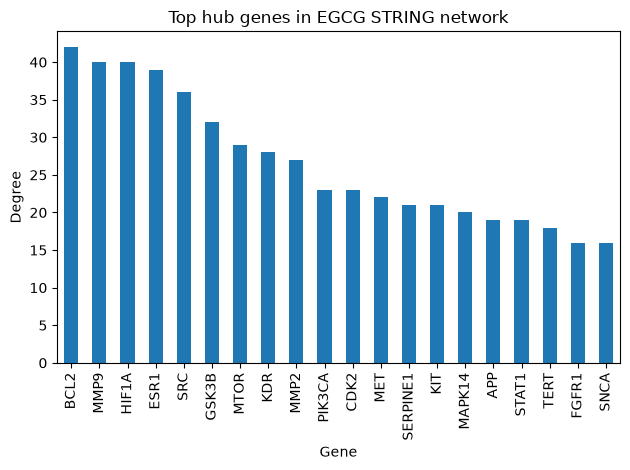

In [23]:
from pathlib import Path

FIGURES_DIR = Path("outputs") / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(10,6))

hub_genes.head(20).plot(
    x="Gene",
    y="Degree",
    kind="bar",
    legend=False
)

plt.title("Top hub genes in EGCG STRING network")
plt.ylabel("Degree")
plt.xlabel("Gene")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "hub_genes_barplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()